# SAE Training on Federated Learning Checkpoints

In [1]:
# Cell 1: Environment Bootstrap
import os
REPO_URL = "https://github.com/ha405/FedMI.git"
BRANCH = "cvpr"

if not os.path.exists("FedMI"):
    get_ipython().system(f"git clone -b {BRANCH} {REPO_URL}")
else:
    # Update repo if already exists to get latest fixes
    get_ipython().system(f"cd FedMI && git pull origin {BRANCH}")

os.chdir("FedMI")

from fedmi.env import setup, CHECKPOINT_DIR, DATA_DIR
setup()

# Install dependencies required by the original notebook
%pip install -q einops opencv-python scikit-image overcomplete

Cloning into 'FedMI'...
remote: Enumerating objects: 669, done.
remote: Counting objects: 100% (297/297), done.
remote: Compressing objects: 100% (217/217), done.
remote: Total 669 (delta 123), reused 231 (delta 78), pack-reused 372 (from 1)
Receiving objects: 100% (669/669), 55.15 MiB | 29.63 MiB/s, done.
Resolving deltas: 100% (221/221), done.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.1/67.1 kB 4.1 MB/s eta 0:00:00


In [6]:
import torch
import torch.nn as nn
from typing import List
import numpy as np
import matplotlib.pyplot as plt
from einops import rearrange
from torch.utils.data import DataLoader, TensorDataset
import json
import os

import overcomplete
from overcomplete.sae import TopKSAE, JumpSAE, BatchTopKSAE, train_sae
from overcomplete.visualization import show, overlay_top_heatmaps

import sys
# sys.path.append('..') # Original path, now unnecessary as we are in the repo root

from core.config import ExperimentConfig
from core.dataset import get_dataset, get_test_dataloader

class SimpleCNN(nn.Module):
    def __init__(self, conv_channels: List[int] = None, num_classes: int = 10, input_channels: int = 1):
        super(SimpleCNN, self).__init__()
        if conv_channels is None:
            conv_channels = [32, 64, 128]

        self.conv1 = nn.Conv2d(input_channels, conv_channels[0], 3, padding=1)
        self.conv2 = nn.Conv2d(conv_channels[0], conv_channels[1], 3, padding=1)
        self.conv3 = nn.Conv2d(conv_channels[1], conv_channels[2], 3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)

        self.spatial_dim = 3 if input_channels == 1 else 4
        self.fc = nn.Linear(conv_channels[2] * self.spatial_dim * self.spatial_dim, num_classes)

    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))
        x = self.pool(torch.relu(self.conv2(x)))
        x = self.pool(torch.relu(self.conv3(x)))
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x

def get_model(config) -> nn.Module:
    in_channels = 1 if config.dataset_name == "MNIST" else 3
    return SimpleCNN(
        conv_channels=config.conv_channels,
        num_classes=5,
        input_channels=in_channels
    ).to(config.device)

def load_config_and_data(config_path):
    with open(config_path, 'r') as f:
        config_dict = json.load(f)
    # Filter out comment keys
    config_dict = {k: v for k, v in config_dict.items() if not k.startswith('_')}
    config = ExperimentConfig(**config_dict)
    # Patch paths for Cloud environment
    config.data_root = DATA_DIR
    _, testset = get_dataset(config)
    test_loader = get_test_dataloader(testset, config)
    return config, testset, test_loader

def load_model_from_checkpoint(config, path):
    model = get_model(config)
    state_dict = torch.load(path, map_location=config.device)
    model.load_state_dict(state_dict['model_state_dict'])
    model.eval()
    return model

def extract_activations(model, dataloader, config):
    model.eval()
    activations = []
    labels = []
    with torch.no_grad():
        for batch in dataloader:
            x, y = batch
            x = x.to(config.device)
            x = model.pool(torch.relu(model.conv1(x)))
            x = model.pool(torch.relu(model.conv2(x)))
            x = model.pool(torch.relu(model.conv3(x)))
            b, c, h, w = x.shape
            x_flat = rearrange(x, 'b c h w -> (b h w) c')
            activations.append(x_flat.cpu())
            y_rep = y.unsqueeze(1).repeat(1, h*w).reshape(-1)
            labels.append(y_rep.cpu())

    activations = torch.cat(activations, dim=0)
    labels = torch.cat(labels, dim=0)

    print(f"Extracted activations from conv3. Shape: {activations.shape}") # Should be [N, 128] if using default channels
    return activations, labels

In [7]:
def train_jump_sae(activations, scenario_name, config):
    subset_size = min(10000, len(activations))
    activations_subset = activations[:subset_size]
    dataset = TensorDataset(activations_subset.to(config.device))
    dataloader = DataLoader(dataset, batch_size=512, shuffle=True)

    print(f"\n--- Training JumpReLU SAE for {scenario_name} ---")
    print(f"Using {subset_size} samples of size {activations.shape[-1]} for SAE training.")

    num_features = activations.shape[-1]
    sae_jump = JumpSAE(num_features, nb_concepts=num_features * 4, bandwidth=1e-2, kernel='silverman', device=config.device)
    optimizer_jump = torch.optim.Adam(sae_jump.parameters(), lr=3e-3)

    desired_sparsity = 0.10

    def criterion_jump(x, x_hat, pre_codes, codes, dictionary):
        loss = (x - x_hat).square().mean()
        sparsity = (codes > 0).float().mean().detach()
        if sparsity > desired_sparsity:
            loss -= sae_jump.thresholds.sum()
        return loss

    logs_jump = train_sae(sae_jump, dataloader, criterion_jump, optimizer_jump, nb_epochs=10, device=config.device)

    print(f"JumpReLU SAE training completed for {scenario_name}.")
    return sae_jump

## IID Experiment

In [8]:
config_iid, testset_iid, test_loader_iid = load_config_and_data('/content/config.json')

# Load IID model - Adjusting path relative to CHECKPOINT_DIR
IID_CHECKPOINT = os.path.join(CHECKPOINT_DIR, 'iid_experiment/checkpoints/checkpoint_round_5.pt')
if not os.path.exists(IID_CHECKPOINT):
    print(f"Checking fallback path for IID...")
    IID_CHECKPOINT = r"/content/iid.pt"

if os.path.exists(IID_CHECKPOINT):
    model_iid = load_model_from_checkpoint(config_iid, IID_CHECKPOINT)
    # Extract activations from 2nd layer
    activations_iid, labels_iid = extract_activations(model_iid, test_loader_iid, config_iid)
    print(f"IID Activations shape: {activations_iid.shape}")
    # Train JumpReLU SAE
    sae_iid = train_jump_sae(activations_iid, "IID", config_iid)
else:
    print(f"\u26a0\ufe0f IID checkpoint not found at {IID_CHECKPOINT}. Ensure experiments have been run.")

Checking fallback path for IID...
Extracted activations from conv3. Shape: torch.Size([46251, 128])
IID Activations shape: torch.Size([46251, 128])

--- Training JumpReLU SAE for IID ---
Using 10000 samples of size 128 for SAE training.
Epoch[1/10], Loss: 1523.5814, R2: 0.6819, L0: 184.5165, Dead Features: 6.1%, Time: 0.1020 seconds
Epoch[2/10], Loss: 1490.1936, R2: 0.9509, L0: 151.6676, Dead Features: 41.4%, Time: 0.1021 seconds
Epoch[3/10], Loss: 1458.6167, R2: 0.9753, L0: 153.5374, Dead Features: 45.3%, Time: 0.1000 seconds
Epoch[4/10], Loss: 1427.3289, R2: 0.9837, L0: 155.8756, Dead Features: 46.3%, Time: 0.0989 seconds
Epoch[5/10], Loss: 1396.1906, R2: 0.9884, L0: 158.3909, Dead Features: 46.5%, Time: 0.1008 seconds
Epoch[6/10], Loss: 1365.1471, R2: 0.9912, L0: 159.6100, Dead Features: 46.5%, Time: 0.1127 seconds
Epoch[7/10], Loss: 1334.1655, R2: 0.9928, L0: 160.0363, Dead Features: 46.5%, Time: 0.1007 seconds
Epoch[8/10], Loss: 1303.2257, R2: 0.9939, L0: 160.4131, Dead Features: 

## Non-IID Experiment

In [9]:
config_niid, testset_niid, test_loader_niid = load_config_and_data('/content/config.json')

# Load Non-IID model - Adjusting path relative to CHECKPOINT_DIR
NIID_CHECKPOINT = os.path.join(CHECKPOINT_DIR, 'niid_experiment/checkpoints/checkpoint_round_10.pt')
if not os.path.exists(NIID_CHECKPOINT):
    print(f"Checking fallback path for NIID...")
    NIID_CHECKPOINT = '/content/noniid.pt'

if os.path.exists(NIID_CHECKPOINT):
    model_niid = load_model_from_checkpoint(config_niid, NIID_CHECKPOINT)
    # Extract activations from 2nd layer
    activations_niid, labels_niid = extract_activations(model_niid, test_loader_niid, config_niid)
    print(f"Non-IID Activations shape: {activations_niid.shape}")
    # Train JumpReLU SAE
    sae_niid = train_jump_sae(activations_niid, "Non-IID", config_niid)
else:
    print(f"\u26a0\ufe0f Non-IID checkpoint not found at {NIID_CHECKPOINT}.")

Checking fallback path for NIID...
Extracted activations from conv3. Shape: torch.Size([46251, 128])
Non-IID Activations shape: torch.Size([46251, 128])

--- Training JumpReLU SAE for Non-IID ---
Using 10000 samples of size 128 for SAE training.
Epoch[1/10], Loss: 1525.1445, R2: 0.6794, L0: 179.1589, Dead Features: 9.0%, Time: 0.1094 seconds
Epoch[2/10], Loss: 1489.5975, R2: 0.9612, L0: 134.6861, Dead Features: 50.0%, Time: 0.1130 seconds
Epoch[3/10], Loss: 1457.1953, R2: 0.9802, L0: 136.5362, Dead Features: 53.1%, Time: 0.0993 seconds
Epoch[4/10], Loss: 1425.3018, R2: 0.9871, L0: 139.6865, Dead Features: 53.1%, Time: 0.0974 seconds
Epoch[5/10], Loss: 1393.7126, R2: 0.9910, L0: 141.7810, Dead Features: 53.1%, Time: 0.1037 seconds
Epoch[6/10], Loss: 1362.3186, R2: 0.9932, L0: 142.2937, Dead Features: 53.5%, Time: 0.0990 seconds
Epoch[7/10], Loss: 1331.0518, R2: 0.9944, L0: 141.7072, Dead Features: 53.5%, Time: 0.1235 seconds
Epoch[8/10], Loss: 1299.8727, R2: 0.9953, L0: 141.3559, Dead F

In [10]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

print("\n==============================")
print("SAE GEOMETRY ANALYSIS START")
print("==============================\n")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

sae_iid = sae_iid.to(device)
sae_niid = sae_niid.to(device)

# Ensure data is on CPU for sklearn/numpy but keep tensors for torch operations
acts_iid_t = torch.as_tensor(activations_iid).float()
acts_niid_t = torch.as_tensor(activations_niid).float()
labs_iid_np = np.array(labels_iid)
labs_niid_np = np.array(labels_niid)

print("IID activation shape:", acts_iid_t.shape)
print("Non-IID activation shape:", acts_niid_t.shape)

# --------------------------------------------------
# 1. Extract dictionary feature vectors
# --------------------------------------------------
print("\n[1] Extracting dictionary feature directions")

# Dict shape: [nb_concepts, d_model]
D_iid = sae_iid.dictionary._weights.detach().cpu()
D_niid = sae_niid.dictionary._weights.detach().cpu()

# Normalize directions to unit sphere for cosine similarity
D_iid_norm = torch.nn.functional.normalize(D_iid, dim=1)
D_niid_norm = torch.nn.functional.normalize(D_niid, dim=1)

print("IID dictionary:", D_iid.shape)
print("Non-IID dictionary:", D_niid.shape)

# --------------------------------------------------
# 2. Cross-model feature similarity
# --------------------------------------------------
print("\n[2] Cross-model feature similarity")

sim_matrix = torch.matmul(D_iid_norm, D_niid_norm.T)
max_sim = sim_matrix.max(dim=1).values

print("Mean max similarity:", max_sim.mean().item())
print("Median max similarity:", max_sim.median().item())

plt.figure(figsize=(6,4))
plt.hist(max_sim.numpy(), bins=50, color='skyblue', edgecolor='black')
plt.title("Max Cosine Similarity (Matched IID vs Non-IID Features)")
plt.xlabel("Cosine Similarity")
plt.show()

# --------------------------------------------------
# 3. Internal feature geometry
# --------------------------------------------------
print("\n[3] Internal feature geometry")

sim_iid = torch.matmul(D_iid_norm, D_iid_norm.T)
sim_niid = torch.matmul(D_niid_norm, D_niid_norm.T)

# Mask diagonal to compare features to others
mask = ~torch.eye(sim_iid.shape[0], dtype=bool)
iid_vals = sim_iid[mask].numpy()
niid_vals = sim_niid[mask].numpy()

print("IID mean pairwise similarity:", iid_vals.mean())
print("Non-IID mean pairwise similarity:", niid_vals.mean())

plt.figure(figsize=(6,4))
plt.hist(iid_vals, bins=60, alpha=0.5, label="IID", density=True)
plt.hist(niid_vals, bins=60, alpha=0.5, label="Non-IID", density=True)
plt.legend()
plt.title("Internal Feature Coherence (Pairwise Similarity)")
plt.show()

# --------------------------------------------------
# 4. PCA visualization
# --------------------------------------------------
print("\n[4] PCA geometry")

pca = PCA(n_components=2)
p_iid = pca.fit_transform(D_iid.numpy())
p_niid = pca.fit_transform(D_niid.numpy())

fig, ax = plt.subplots(1, 2, figsize=(12,5))
ax[0].scatter(p_iid[:,0], p_iid[:,1], alpha=0.6, c='blue')
ax[0].set_title("IID Feature Space (PCA)")
ax[1].scatter(p_niid[:,0], p_niid[:,1], alpha=0.6, c='red')
ax[1].set_title("Non-IID Feature Space (PCA)")
plt.show()

# --------------------------------------------------
# 5. Encode activations through SAE
# --------------------------------------------------
print("\n[5] Computing SAE feature activations")

def encode_features(sae, activations):
    x = activations.to(device)
    with torch.no_grad():
        z = sae.encode(x)
    if isinstance(z, tuple): z = z[0]
    return z.detach().cpu()

f_iid = encode_features(sae_iid, acts_iid_t)
f_niid = encode_features(sae_niid, acts_niid_t)

print("IID active feature fraction:", (f_iid > 0).float().mean().item())
print("Non-IID active feature fraction:", (f_niid > 0).float().mean().item())

# --------------------------------------------------
# 6. Feature utilization entropy
# --------------------------------------------------
print("\n[6] Feature entropy")

def feature_entropy(features):
    # Calculate how often each feature is used (probability distribution over features)
    usage = (features > 0).float().sum(0)
    p = usage / (usage.sum() + 1e-8)
    # Shannon Entropy: -sum(p * log p)
    entropy = -(p * torch.log(p + 1e-8)).sum()
    # Normalized Entropy (0 to 1)
    max_entropy = np.log(features.shape[1])
    return entropy / max_entropy

ent_iid = feature_entropy(f_iid)
ent_niid = feature_entropy(f_niid)

print(f"IID Normalized Feature Entropy: {ent_iid.item():.4f}")
print(f"Non-IID Normalized Feature Entropy: {ent_niid.item():.4f}")
print("(High entropy = model uses features uniformly; Low = model relies on very few features)")

# --------------------------------------------------
# 7. Buried knowledge test (Per-Class Projection)
# --------------------------------------------------
print("\n[7] Per-Class Projection: Non-IID activations onto IID features")

# Project Non-IID raw activations onto the IID dictionary directions
# This tells us: "Do the Non-IID activations contain the concepts learned by the IID model?"
proj_niid_on_iid = acts_niid_t @ D_iid_norm.T

classes = np.unique(labs_niid_np)
per_class_stats = {}

for cls in classes:
    mask = (labs_niid_np == cls)
    if not np.any(mask): continue

    cls_projections = proj_niid_on_iid[mask]
    avg_proj = cls_projections.mean().item()
    max_feat_val, max_feat_idx = cls_projections.mean(0).max(0)

    per_class_stats[cls] = {'avg': avg_proj, 'top_feat': max_feat_idx.item(), 'top_val': max_feat_val.item()}
    print(f"Class {int(cls)} | Mean Projection: {avg_proj:.4f} | Strongest IID Feature: {max_feat_idx.item()} (val: {max_feat_val.item():.4f})")

# --------------------------------------------------
# 8. Similarity heatmaps
# --------------------------------------------------
print("\n[8] Feature similarity heatmaps")

fig, ax = plt.subplots(1, 2, figsize=(16, 6))
sns.heatmap(sim_iid.numpy()[:100, :100], cmap="RdBu_r", center=0, ax=ax[0])
ax[0].set_title("IID Feature Similarity (Subset 100x100)")
sns.heatmap(sim_niid.numpy()[:100, :100], cmap="RdBu_r", center=0, ax=ax[1])
ax[1].set_title("Non-IID Feature Similarity (Subset 100x100)")
plt.show()

print("\n==============================")
print("ANALYSIS COMPLETE")
print("==============================")

In [ ]:
from fedmi.env import show_images
show_images()

## Download Results

In [ ]:
import shutil
from IPython.display import FileLink

if os.path.isdir(CHECKPOINT_DIR):
    output_zip = "sae_experiment_results.zip"
    shutil.make_archive(output_zip.replace('.zip', ''), 'zip', CHECKPOINT_DIR)
    print(f"Results zipped to {output_zip}")
    display(FileLink(output_zip))
else:
    print("⚠ No results found in checkpoint directory.")

USAE


UNIVERSAL SAE (USAE) TRAINING (FOR CONV3)

Training Universal SAE on conv3 features (Dim=128).
Shared Concepts: 512 | TopK: 25 | Epochs: 100
Epoch 01/100 - Total Universal Loss: 1582.5057
Epoch 05/100 - Total Universal Loss: 552.3466
Epoch 10/100 - Total Universal Loss: 258.5275
Epoch 15/100 - Total Universal Loss: 219.4330
Epoch 20/100 - Total Universal Loss: 208.7910
Epoch 25/100 - Total Universal Loss: 198.1102
Epoch 30/100 - Total Universal Loss: 192.4519
Epoch 35/100 - Total Universal Loss: 191.1809
Epoch 40/100 - Total Universal Loss: 187.3426
Epoch 45/100 - Total Universal Loss: 183.0230
Epoch 50/100 - Total Universal Loss: 184.1332
Epoch 55/100 - Total Universal Loss: 181.5122
Epoch 60/100 - Total Universal Loss: 180.9240
Epoch 65/100 - Total Universal Loss: 178.0293
Epoch 70/100 - Total Universal Loss: 178.3854
Epoch 75/100 - Total Universal Loss: 177.7257
Epoch 80/100 - Total Universal Loss: 172.9754
Epoch 85/100 - Total Universal Loss: 175.9032
Epoch 90/100 - Total Universa

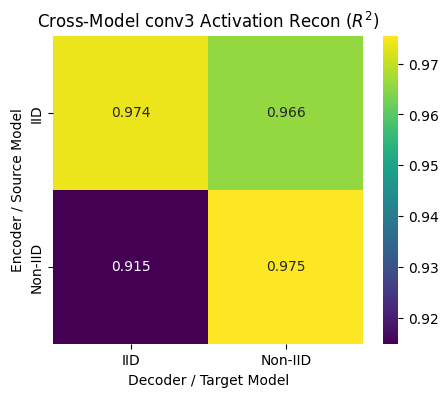

In [15]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import random
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("\n===========================================")
print("UNIVERSAL SAE (USAE) TRAINING (FOR CONV3)")
print("===========================================\n")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class UniversalSAE(nn.Module):
    """
    Universal Sparse Autoencoder (USAE)
    Learns a shared concept space Z across M different models.
    """
    def __init__(self, num_models, input_dim, num_concepts, top_k=32):
        super().__init__()
        self.num_models = num_models
        self.input_dim = input_dim
        self.num_concepts = num_concepts
        self.top_k = top_k

        # M Encoders
        self.W_enc = nn.ParameterList([
            nn.Parameter(torch.randn(input_dim, num_concepts) / (input_dim**0.5))
            for _ in range(num_models)
        ])
        self.b_pre = nn.ParameterList([
            nn.Parameter(torch.zeros(input_dim))
            for _ in range(num_models)
        ])

        # Batch Norm per model (following Appendix A.1)
        self.bn = nn.ModuleList([
            nn.BatchNorm1d(num_concepts)
            for _ in range(num_models)
        ])

        # M Decoders
        self.D = nn.ParameterList([
            nn.Parameter(torch.randn(num_concepts, input_dim) / (num_concepts**0.5))
            for _ in range(num_models)
        ])

    def encode(self, x, model_idx):
        # Apply pre-bias and encode
        h = (x - self.b_pre[model_idx]) @ self.W_enc[model_idx]
        # BatchNorm and ReLU
        h = F.relu(self.bn[model_idx](h))

        # TopK Sparsity Enforcement
        top_vals, top_idx = torch.topk(h, self.top_k, dim=-1)
        z = torch.zeros_like(h)
        z.scatter_(-1, top_idx, top_vals)
        return z

    def decode(self, z, model_idx):
        return z @ self.D[model_idx]


min_size = min(len(activations_iid), len(activations_niid))

# subsample to avoid VRAM Out-of-Memory
subset_size = min(20000, min_size)
A_iid_t = activations_iid[:subset_size].to(device)
A_niid_t = activations_niid[:subset_size].to(device)

dataset = TensorDataset(A_iid_t, A_niid_t)
dataloader = DataLoader(dataset, batch_size=512, shuffle=True)

input_dim = A_iid_t.shape[-1]
expansion_factor = 4          # 4x overcomplete
num_concepts = input_dim * expansion_factor
top_k = int(num_concepts * 0.05) # Enforce 5% sparsity

usae = UniversalSAE(
    num_models=2,
    input_dim=input_dim,
    num_concepts=num_concepts,
    top_k=top_k
).to(device)

# Using a single global optimizer ensures that ALL decoders update
optimizer = torch.optim.Adam(usae.parameters(), lr=1e-3)

num_epochs = 100
print(f"Training Universal SAE on conv3 features (Dim={input_dim}).")
print(f"Shared Concepts: {num_concepts} | TopK: {top_k} | Epochs: {num_epochs}")

usae.train()
for epoch in range(num_epochs):
    total_loss = 0.0
    for batch in dataloader:
        A_batch = batch
        i = random.randint(0, usae.num_models - 1)
        optimizer.zero_grad()
        Z = usae.encode(A_batch[i], i)
        loss = 0.0
        for j in range(usae.num_models):
            A_hat_j = usae.decode(Z, j)
            loss += torch.norm(A_batch[j] - A_hat_j, p='fro')

        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Epoch {epoch+1:02d}/{num_epochs} - Total Universal Loss: {total_loss/len(dataloader):.4f}")

print("USAE training completed.")
print("\n[Evaluating Cross-Model Activation Reconstruction (R^2 Score)]")

def calculate_r2(true_A, recon_A):
    ss_res = ((true_A - recon_A)**2).sum()
    ss_tot = ((true_A - true_A.mean(dim=0))**2).sum()
    return max(0.0, (1 - ss_res / ss_tot).item())

usae.eval()
with torch.no_grad():
    labels = ["IID", "Non-IID"]
    A_eval = [A_iid_t, A_niid_t]

    # Store R^2 matrix [Encoder_i, Decoder_j]
    r2_matrix = np.zeros((2, 2))

    for i in range(2):
        Z = usae.encode(A_eval[i], i)
        for j in range(2):
            A_hat = usae.decode(Z, j)
            r2_matrix[i, j] = calculate_r2(A_eval[j], A_hat)

    print(f"{'Encoder':<15} | {'Decoder':<15} | R^2 Score")
    print("-" * 45)
    for i in range(2):
        for j in range(2):
            recons_type = "Self-Recon" if i == j else "Cross-Recon"
            print(f"{labels[i]:<15} | {labels[j]:<15} | {r2_matrix[i,j]:.4f} ({recons_type})")

print("\n[Checking Sparsity Level]")

with torch.no_grad():
    Z_iid = usae.encode(A_iid_t, 0)
    Z_niid = usae.encode(A_niid_t, 1)

    iid_active = (Z_iid > 0).float().sum(dim=1).mean().item()
    niid_active = (Z_niid > 0).float().sum(dim=1).mean().item()

print(f"Expected active concepts (TopK): {top_k}")
print(f"IID avg active concepts: {iid_active:.2f}")
print(f"Non-IID avg active concepts: {niid_active:.2f}")

# Visualizing the R2 Matrix
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(r2_matrix, annot=True, fmt=".3f", cmap="viridis",
            xticklabels=labels, yticklabels=labels, ax=ax)
ax.set_title("Cross-Model conv3 Activation Recon ($R^2$)")
ax.set_xlabel("Decoder / Target Model")
ax.set_ylabel("Encoder / Source Model")
plt.show()

Total Active Concepts: 512 / 512
Concepts Unique to IID Model: 84
Concepts Unique to Non-IID Model: 50


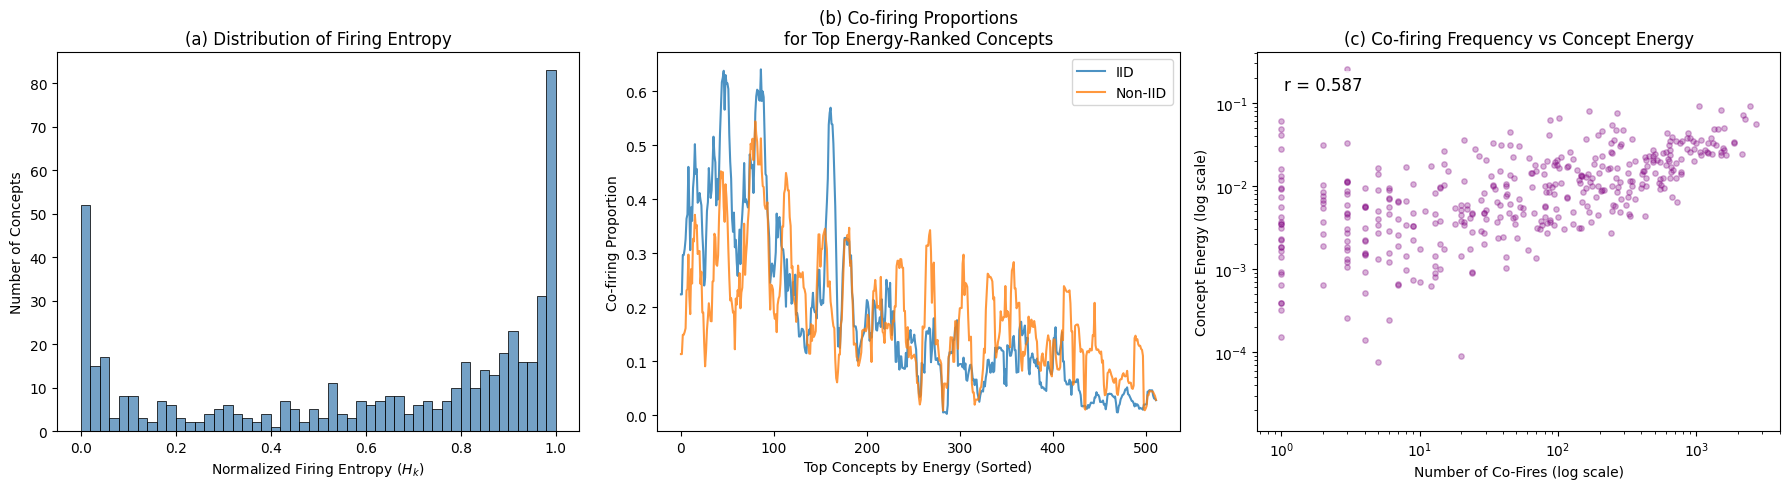

In [20]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

usae.eval()
with torch.no_grad():
    Z_iid = usae.encode(A_iid_t, 0)
    Z_niid = usae.encode(A_niid_t, 1)
    fires_iid = (Z_iid > 0).float()
    fires_niid = (Z_niid > 0).float()
    co_fires = fires_iid * fires_niid

    total_iid = fires_iid.sum(dim=0)
    total_niid = fires_niid.sum(dim=0)
    total_co_fires = co_fires.sum(dim=0)
    total_any_fires = total_iid + total_niid
    active_mask = total_any_fires > 0
    p_iid = total_iid / (total_any_fires + 1e-9)
    p_niid = total_niid / (total_any_fires + 1e-9)
    p_iid_active = p_iid[active_mask]
    p_niid_active = p_niid[active_mask]
    entropy_active = -(p_iid_active * torch.log2(p_iid_active + 1e-9) +
                       p_niid_active * torch.log2(p_niid_active + 1e-9))

    def get_concept_energies(Z, decoder_weights):
        expected_Z = Z.mean(dim=0)
        contributions = expected_Z.unsqueeze(1) * decoder_weights
        return torch.norm(contributions, p=2, dim=1)**2

    energy_iid = get_concept_energies(Z_iid, usae.D[0])
    energy_niid = get_concept_energies(Z_niid, usae.D[1])
    avg_energy = (energy_iid + energy_niid) / 2.0

    cfp_iid = total_co_fires / (total_iid + 1e-9)
    cfp_niid = total_co_fires / (total_niid + 1e-9)

    sorted_indices = torch.argsort(avg_energy, descending=True)
    top_k_plot = min(1000, len(sorted_indices))

    sorted_cfp_iid = cfp_iid[sorted_indices][:top_k_plot].cpu().numpy()
    sorted_cfp_niid = cfp_niid[sorted_indices][:top_k_plot].cpu().numpy()

    unique_to_iid = torch.where((total_iid > 10) & (p_iid > 0.95))[0]
    unique_to_niid = torch.where((total_niid > 10) & (p_niid > 0.95))[0]

    print(f"Total Active Concepts: {active_mask.sum().item()} / {Z_iid.shape[1]}")
    print(f"Concepts Unique to IID Model: {len(unique_to_iid)}")
    print(f"Concepts Unique to Non-IID Model: {len(unique_to_niid)}")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.histplot(entropy_active.cpu().numpy(), bins=50, ax=axes[0], color='steelblue')
axes[0].set_title("(a) Distribution of Firing Entropy")
axes[0].set_xlabel("Normalized Firing Entropy ($H_k$)")
axes[0].set_ylabel("Number of Concepts")
axes[0].set_xlim(-0.05, 1.05)
def smooth(y, box_pts):
    box = np.ones(box_pts)/box_pts
    return np.convolve(y, box, mode='same')

axes[1].plot(smooth(sorted_cfp_iid, 10), label='IID', alpha=0.8)
axes[1].plot(smooth(sorted_cfp_niid, 10), label='Non-IID', alpha=0.8)
axes[1].set_title("(b) Co-firing Proportions\nfor Top Energy-Ranked Concepts")
axes[1].set_xlabel("Top Concepts by Energy (Sorted)")
axes[1].set_ylabel("Co-firing Proportion")
axes[1].legend()

x_data = total_co_fires[active_mask].cpu().numpy()
y_data = avg_energy[active_mask].cpu().numpy()

axes[2].scatter(x_data, y_data, alpha=0.3, s=15, color='purple')
axes[2].set_title("(c) Co-firing Frequency vs Concept Energy")
axes[2].set_xlabel("Number of Co-Fires (log scale)")
axes[2].set_ylabel("Concept Energy (log scale)")
axes[2].set_xscale('log')
axes[2].set_yscale('log')

valid = (x_data > 0) & (y_data > 0)
if valid.sum() > 1:
    r = np.corrcoef(np.log10(x_data[valid]), np.log10(y_data[valid]))[0, 1]
    axes[2].text(0.05, 0.9, f"r = {r:.3f}", transform=axes[2].transAxes, fontsize=12,
                 bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))

plt.tight_layout()
plt.show()

In [22]:
import torch
from tqdm import tqdm
from einops import rearrange
import numpy as np

def get_accuracy(model, dataloader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for x, y in dataloader:
            x, y = x.to(device), y.to(device)
            outputs = model(x)
            _, predicted = torch.max(outputs.data, 1)
            total += y.size(0)
            correct += (predicted == y).sum().item()
    return correct / total

def evaluate_usae_performance(source_idx, target_idx, source_model, target_model, usae, dataloader, mask=None):
    source_model.eval()
    target_model.eval()
    usae.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for x, y in dataloader:
            x, y = x.to(device), y.to(device)
            feat = source_model.pool(torch.relu(source_model.conv1(x)))
            feat = source_model.pool(torch.relu(source_model.conv2(feat)))
            feat = source_model.pool(torch.relu(source_model.conv3(feat)))
            b, c, h, w = feat.shape
            feat_flat = rearrange(feat, 'b c h w -> (b h w) c')
            Z = usae.encode(feat_flat, source_idx)
            if mask is not None:
                Z = Z * mask
            recon_flat = usae.decode(Z, target_idx)
            recon_feat = rearrange(recon_flat, '(b h w) c -> b c h w', b=b, h=h, w=w).contiguous()
            out = recon_feat.reshape(recon_feat.size(0), -1)
            logits = target_model.fc(out)
            _, predicted = torch.max(logits.data, 1)
            total += y.size(0)
            correct += (predicted == y).sum().item()
    return correct / total

usae.eval()
with torch.no_grad():
    Z_iid = usae.encode(A_iid_t, 0)
    Z_niid = usae.encode(A_niid_t, 1)
    active_iid = (Z_iid > 0).any(dim=0)
    active_niid = (Z_niid > 0).any(dim=0)

    mask_shared = (active_iid & active_niid).float()
    mask_iid_only = (active_iid & ~active_niid).float()
    mask_niid_only = (~active_iid & active_niid).float()

families = [
    ("Shared Concepts", mask_shared),
    ("IID-Unique Concepts", mask_iid_only),
    ("Non-IID-Unique Concepts", mask_niid_only)
]

print("Calculating Baselines...")
acc_iid_base = get_accuracy(model_iid, test_loader_iid)
acc_niid_base = get_accuracy(model_niid, test_loader_niid)

print("\n" + "="*85)
print(f"{'Concept Family':<25} | {'Source':<8} -> {'Target':<8} | Accuracy | % of Base")
print("-" * 85)

for name, mask in families:
    active_count = int(mask.sum().item())

    acc_ii = evaluate_usae_performance(0, 0, model_iid, model_iid, usae, test_loader_iid, mask)
    acc_nn = evaluate_usae_performance(1, 1, model_niid, model_niid, usae, test_loader_niid, mask)
    acc_in = evaluate_usae_performance(0, 1, model_iid, model_niid, usae, test_loader_iid, mask)
    acc_ni = evaluate_usae_performance(1, 0, model_niid, model_iid, usae, test_loader_niid, mask)

    print(f"{name:<25} ({active_count:3d} concepts)")
    print(f"{'':<25} | {'IID':<8} -> {'IID':<8} | {acc_ii:.4f}   | {(acc_ii/acc_iid_base)*100:6.1f}%")
    print(f"{'':<25} | {'NIID':<8} -> {'NIID':<8} | {acc_nn:.4f}   | {(acc_nn/acc_niid_base)*100:6.1f}%")
    print(f"{'':<25} | {'IID':<8} -> {'NIID':<8} | {acc_in:.4f}   | {(acc_in/acc_niid_base)*100:6.1f}%")
    print(f"{'':<25} | {'NIID':<8} -> {'IID':<8} | {acc_ni:.4f}   | {(acc_ni/acc_iid_base)*100:6.1f}%")
    print("-" * 85)

print(f"{'Full USAE (All)':<25}")
acc_full_in = evaluate_usae_performance(0, 1, model_iid, model_niid, usae, test_loader_iid)
acc_full_ni = evaluate_usae_performance(1, 0, model_niid, model_iid, usae, test_loader_niid)
print(f"{'':<25} | {'IID':<8} -> {'NIID':<8} | {acc_full_in:.4f}   | {(acc_full_in/acc_niid_base)*100:6.1f}%")
print(f"{'':<25} | {'NIID':<8} -> {'IID':<8} | {acc_full_ni:.4f}   | {(acc_full_ni/acc_iid_base)*100:6.1f}%")
print("="*85)

Calculating Baselines...

Concept Family            | Source   -> Target   | Accuracy | % of Base
-------------------------------------------------------------------------------------
Shared Concepts           (480 concepts)
                          | IID      -> IID      | 0.9702   |   99.7%
                          | NIID     -> NIID     | 0.7671   |  100.1%
                          | IID      -> NIID     | 0.7813   |  101.9%
                          | NIID     -> IID      | 0.9463   |   97.3%
-------------------------------------------------------------------------------------
IID-Unique Concepts       ( 22 concepts)
                          | IID      -> IID      | 0.6853   |   70.5%
                          | NIID     -> NIID     | 0.2209   |   28.8%
                          | IID      -> NIID     | 0.3551   |   46.3%
                          | NIID     -> IID      | 0.2209   |   22.7%
-------------------------------------------------------------------------------------
No

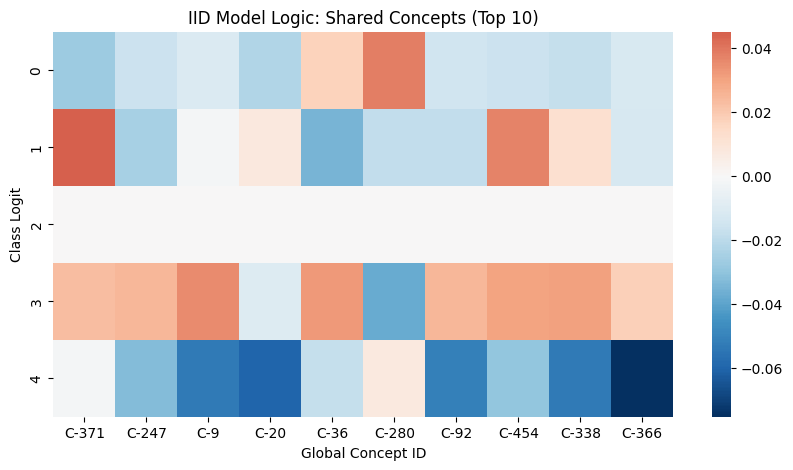

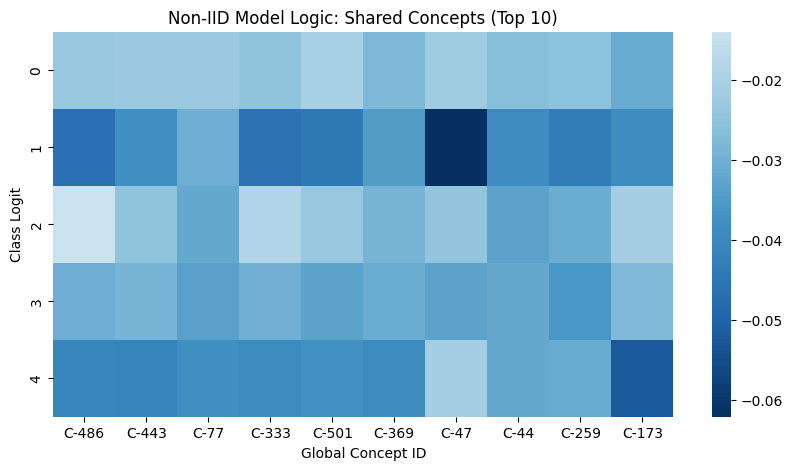

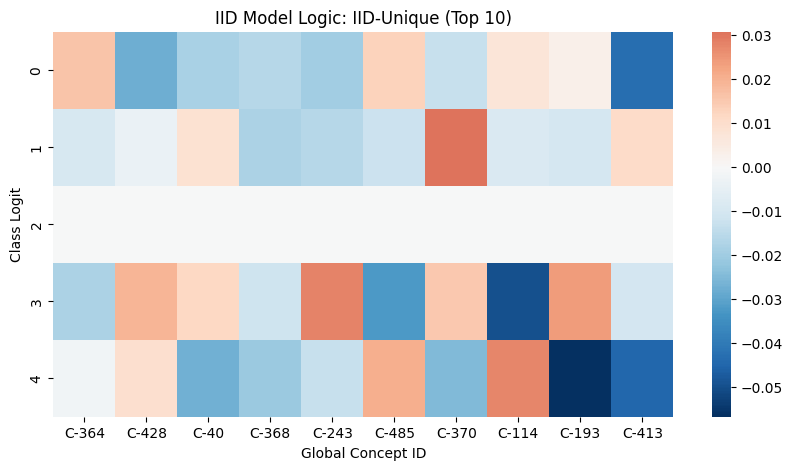

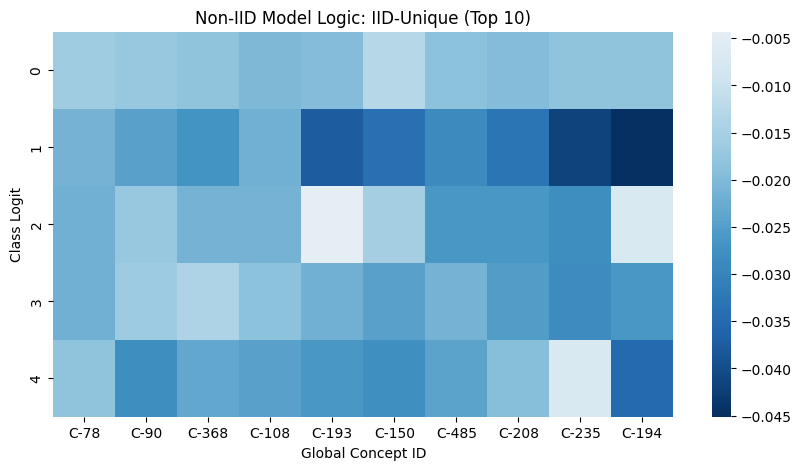

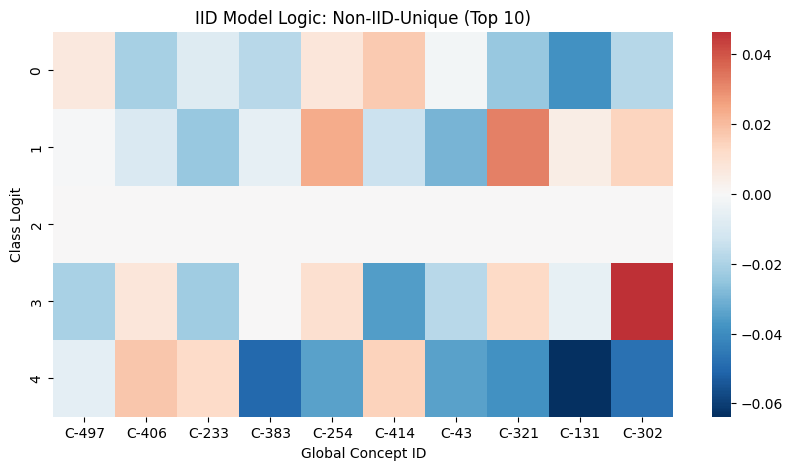

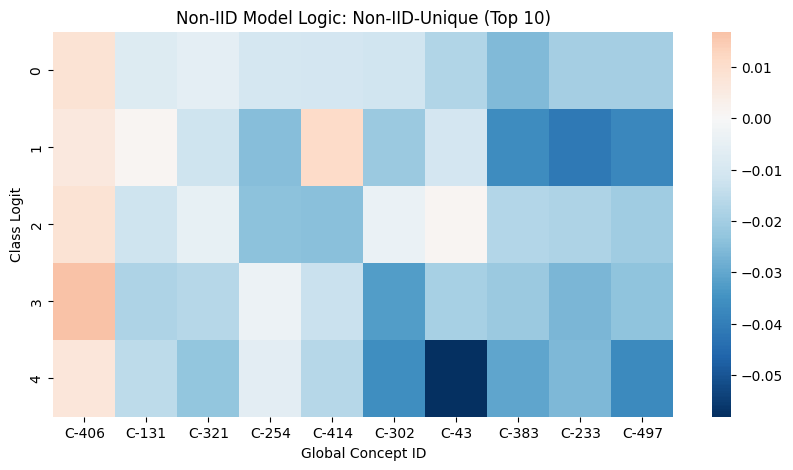

/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


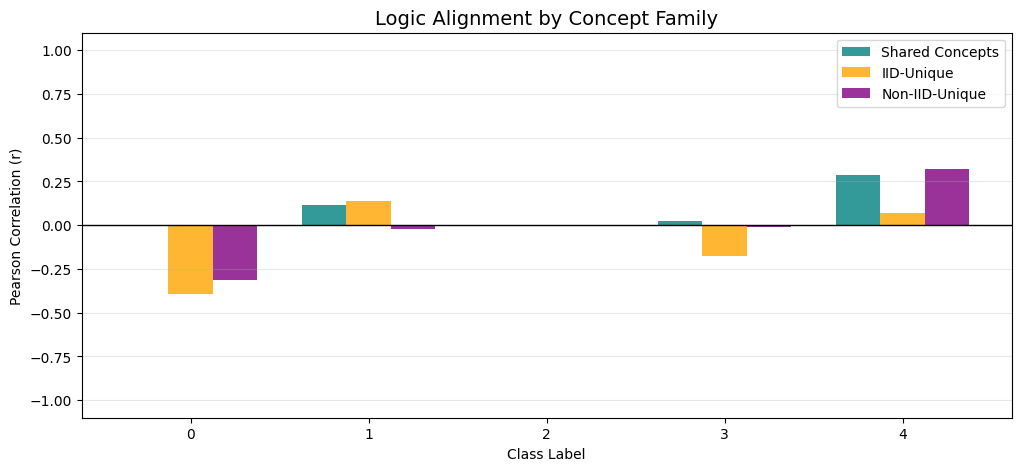

In [34]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def get_logit_influence_robust(usae_model, model_idx, target_model):
    D = usae_model.D[model_idx].detach()
    num_concepts, feat_dim = D.shape
    W_fc = target_model.fc.weight.detach()
    num_classes, total_fc_input = W_fc.shape
    spatial_size = total_fc_input // feat_dim
    W_fc_reduced = W_fc.view(num_classes, feat_dim, spatial_size).mean(dim=2)
    influence = D @ W_fc_reduced.t()
    return influence.cpu().numpy(), num_classes

inf_iid, n_cls = get_logit_influence_robust(usae, 0, model_iid)
inf_niid, _ = get_logit_influence_robust(usae, 1, model_niid)

families = [
    ("Shared Concepts", np.where(mask_shared.cpu().numpy() > 0)[0]),
    ("IID-Unique", np.where(mask_iid_only.cpu().numpy() > 0)[0]),
    ("Non-IID-Unique", np.where(mask_niid_only.cpu().numpy() > 0)[0])
]

def plot_family_influence(inf_matrix, family_indices, title, n_classes):
    if len(family_indices) == 0:
        return

    family_inf = inf_matrix[family_indices]
    loudness = np.abs(family_inf).sum(axis=1)
    local_top_idx = np.argsort(loudness)[-10:]
    global_indices = family_indices[local_top_idx]

    plt.figure(figsize=(10, 5))
    sns.heatmap(family_inf[local_top_idx].T, cmap="RdBu_r", center=0,
                yticklabels=range(n_classes),
                xticklabels=[f"C-{i}" for i in global_indices])
    plt.title(f"{title} (Top 10)", fontsize=12)
    plt.ylabel("Class Logit")
    plt.xlabel("Global Concept ID")
    plt.show()

for name, indices in families:
    plot_family_influence(inf_iid, indices, f"IID Model Logic: {name}", n_cls)
    plot_family_influence(inf_niid, indices, f"Non-IID Model Logic: {name}", n_cls)

plt.figure(figsize=(12, 5))
colors = ['teal', 'orange', 'purple']
x = np.arange(n_cls)
width = 0.25

for i, (name, indices) in enumerate(families):
    if len(indices) < 2:
        continue
    family_corr = []
    for c in range(n_cls):
        r = np.corrcoef(inf_iid[indices, c], inf_niid[indices, c])[0, 1]
        family_corr.append(np.nan_to_num(r))

    plt.bar(x + (i * width), family_corr, width, label=name, color=colors[i], alpha=0.8)

plt.axhline(0, color='black', linewidth=1)
plt.xticks(x + width, range(n_cls))
plt.title("Logic Alignment by Concept Family", fontsize=14)
plt.xlabel("Class Label")
plt.ylabel("Pearson Correlation (r)")
plt.ylim(-1.1, 1.1)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

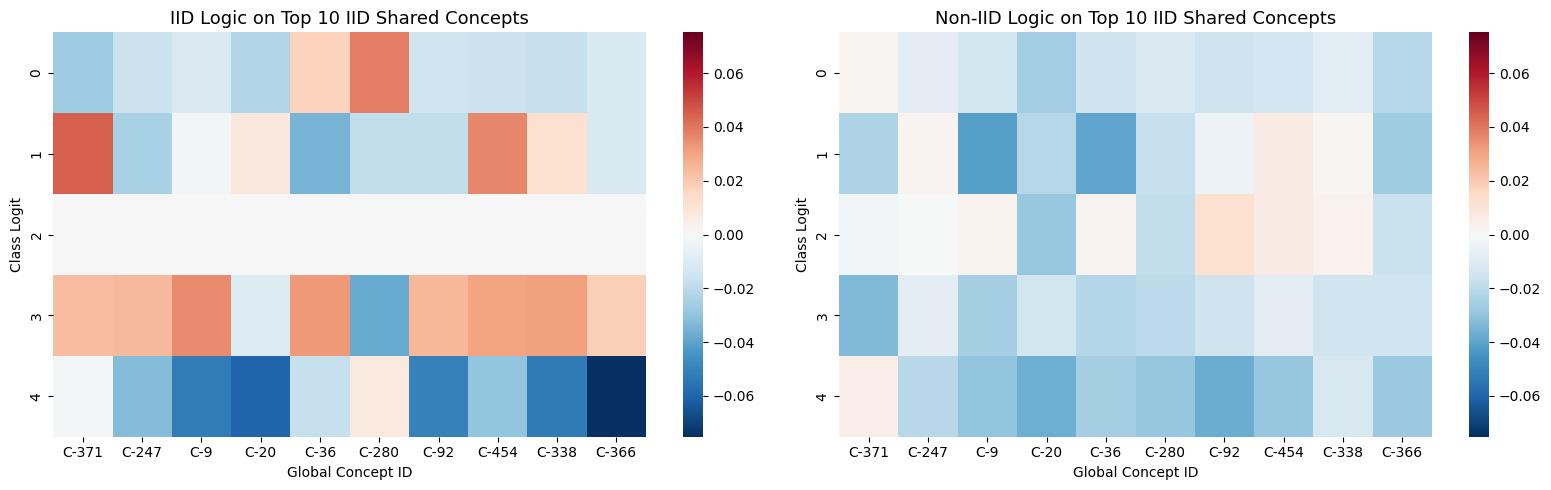

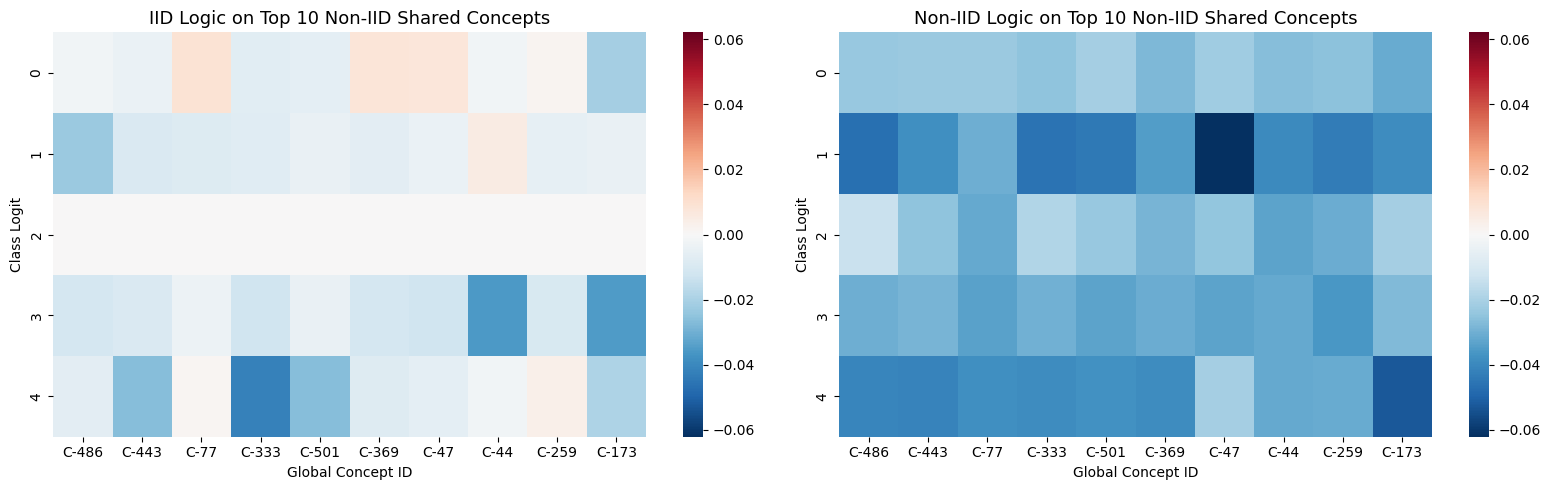

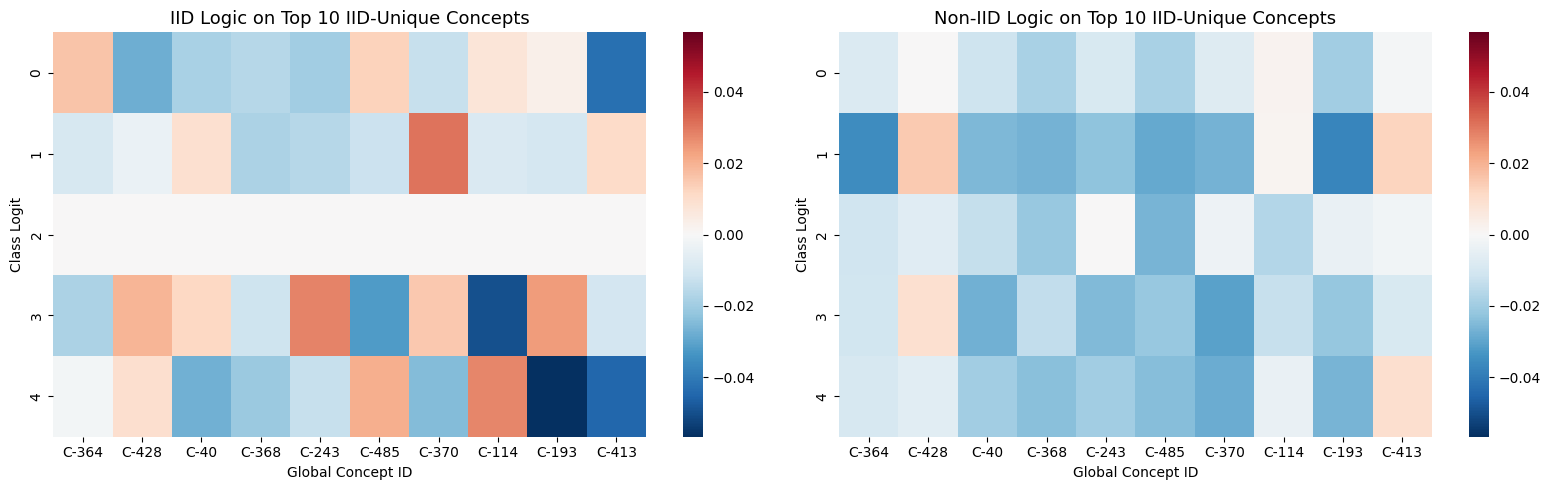

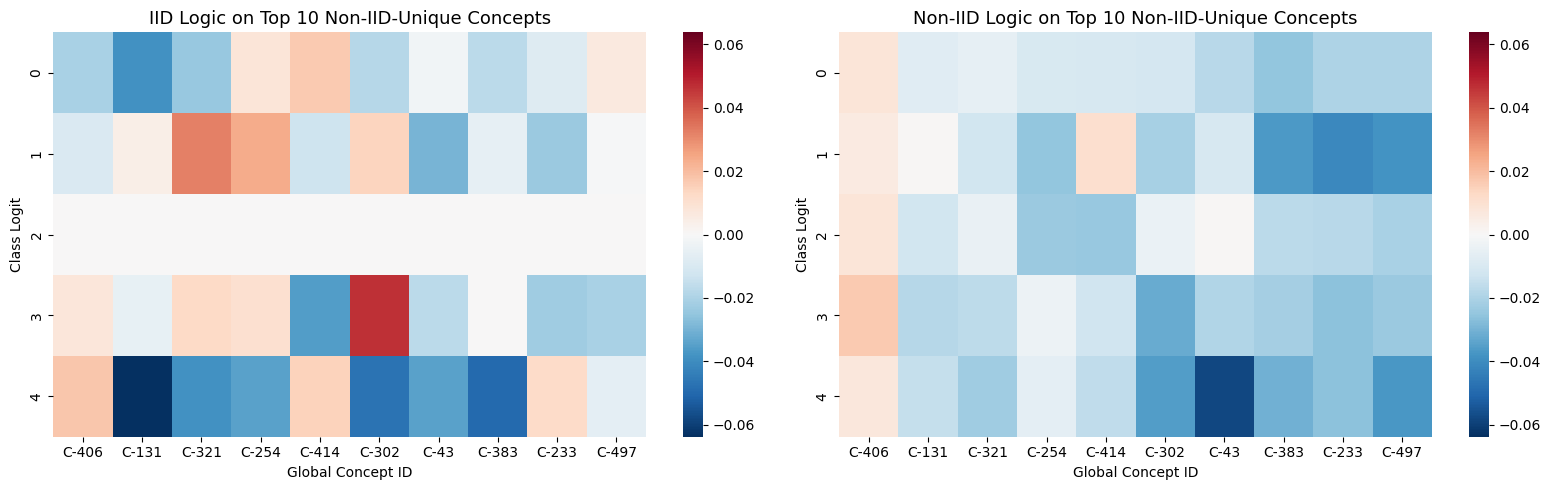

/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


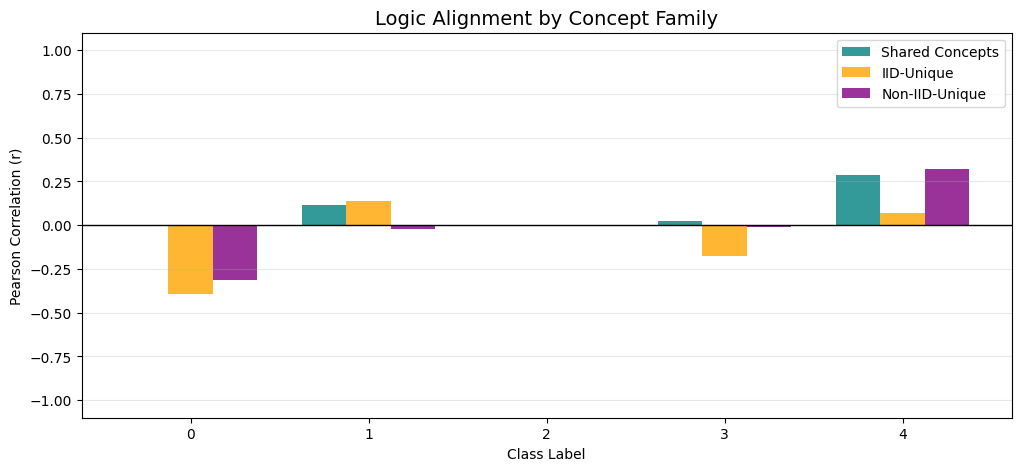

In [35]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def get_logit_influence_robust(usae_model, model_idx, target_model):
    D = usae_model.D[model_idx].detach()
    num_concepts, feat_dim = D.shape
    W_fc = target_model.fc.weight.detach()
    num_classes, total_fc_input = W_fc.shape
    spatial_size = total_fc_input // feat_dim
    W_fc_reduced = W_fc.view(num_classes, feat_dim, spatial_size).mean(dim=2)
    influence = D @ W_fc_reduced.t()
    return influence.cpu().numpy(), num_classes

inf_iid, n_cls = get_logit_influence_robust(usae, 0, model_iid)
inf_niid, _ = get_logit_influence_robust(usae, 1, model_niid)

families = [
    ("Shared Concepts", np.where(mask_shared.cpu().numpy() > 0)[0]),
    ("IID-Unique", np.where(mask_iid_only.cpu().numpy() > 0)[0]),
    ("Non-IID-Unique", np.where(mask_niid_only.cpu().numpy() > 0)[0])
]

def plot_cross_comparison(indices, source_matrix, name_source):
    if len(indices) == 0:
        return
    loudness = np.abs(source_matrix[indices]).sum(axis=1)
    top_local = np.argsort(loudness)[-10:]
    top_global = indices[top_local]

    vmax = max(np.abs(inf_iid[top_global]).max(), np.abs(inf_niid[top_global]).max())
    vmin = -vmax

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    sns.heatmap(inf_iid[top_global].T, cmap="RdBu_r", center=0, vmin=vmin, vmax=vmax,
                yticklabels=range(n_cls), xticklabels=[f"C-{i}" for i in top_global], ax=axes[0])
    axes[0].set_title(f"IID Logic on Top 10 {name_source}", fontsize=13)
    axes[0].set_ylabel("Class Logit")
    axes[0].set_xlabel("Global Concept ID")

    sns.heatmap(inf_niid[top_global].T, cmap="RdBu_r", center=0, vmin=vmin, vmax=vmax,
                yticklabels=range(n_cls), xticklabels=[f"C-{i}" for i in top_global], ax=axes[1])
    axes[1].set_title(f"Non-IID Logic on Top 10 {name_source}", fontsize=13)
    axes[1].set_ylabel("Class Logit")
    axes[1].set_xlabel("Global Concept ID")

    plt.tight_layout()
    plt.show()

shared_idx = families[0][1]
plot_cross_comparison(shared_idx, inf_iid, "IID Shared Concepts")
plot_cross_comparison(shared_idx, inf_niid, "Non-IID Shared Concepts")

plot_cross_comparison(families[1][1], inf_iid, "IID-Unique Concepts")
plot_cross_comparison(families[2][1], inf_niid, "Non-IID-Unique Concepts")

plt.figure(figsize=(12, 5))
colors = ['teal', 'orange', 'purple']
x = np.arange(n_cls)
width = 0.25

for i, (name, indices) in enumerate(families):
    if len(indices) < 2:
        continue
    family_corr = []
    for c in range(n_cls):
        r = np.corrcoef(inf_iid[indices, c], inf_niid[indices, c])[0, 1]
        family_corr.append(np.nan_to_num(r))

    plt.bar(x + (i * width), family_corr, width, label=name, color=colors[i], alpha=0.8)

plt.axhline(0, color='black', linewidth=1)
plt.xticks(x + width, range(n_cls))
plt.title("Logic Alignment by Concept Family", fontsize=14)
plt.xlabel("Class Label")
plt.ylabel("Pearson Correlation (r)")
plt.ylim(-1.1, 1.1)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

In [37]:
def verify_specific_class_logic(model, usae, dataloader, model_idx, influence_matrix, target_class=1):
    model.eval()
    usae.eval()

    found_img = None
    found_label = None

    # 1. Search for an image of the target_class
    for images, labels in dataloader:
        match_idx = (labels == target_class).nonzero()
        if len(match_idx) > 0:
            idx = match_idx[0].item()
            found_img = images[idx:idx+1].to(device)
            found_label = labels[idx].item()
            break

    if found_img is None:
        print(f"Could not find Class {target_class} in dataloader.")
        return

    with torch.no_grad():
        # 2. Forward pass
        x = model.pool(torch.relu(model.conv1(found_img)))
        x = model.pool(torch.relu(model.conv2(x)))
        x = model.pool(torch.relu(model.conv3(x)))

        logits_total = model.fc(x.view(1, -1)).squeeze(0)

        b, c, h, w = x.shape
        flat_x = rearrange(x, 'b c h w -> (b h w) c')
        Z = usae.encode(flat_x, model_idx)
        z_sums = Z.sum(dim=0).cpu().numpy()

        # 3. Calculate Push: Activation * Heatmap_Weight
        all_pushes = z_sums[:, np.newaxis] * influence_matrix

        # Find the concept that provided the BIGGEST POSITIVE LIFT for this class
        top_concept_idx = np.argmax(all_pushes[:, target_class])
        max_push = all_pushes[top_concept_idx, target_class]

        # Find the winning margin
        sorted_logits, _ = torch.sort(logits_total, descending=True)
        margin = sorted_logits[0] - sorted_logits[1]

    print(f"--- VERIFICATION FOR CLASS {target_class} ---")
    print(f"Model Prediction: {torch.argmax(logits_total).item()} (Logit: {logits_total[target_class]:.2f})")
    print(f"Winning Margin: {margin.item():.4f}")
    print("-" * 30)
    print(f"TOP CONTRIBUTOR: Concept C-{top_concept_idx}")
    print(f"Activation (Z): {z_sums[top_concept_idx]:.4f}")
    print(f"Heatmap Weight: {influence_matrix[top_concept_idx, target_class]:.4f}")
    print(f"RESULTING PUSH: +{max_push:.4f} logit points")

    impact = (max_push / margin.item()) * 100
    print(f"\nSIGNIFICANCE: This one concept accounts for {impact:.1f}% of the winning margin.")

    if impact > 15:
        print("STATUS: SUCCESS. Heatmap values are mathematically significant.")
    else:
        print("STATUS: LOW IMPACT. Looking for a louder concept...")

# Run for Class 1 (Should show strong positive logic)
verify_specific_class_logic(model_iid, usae, test_loader_iid, 0, inf_iid, target_class=1)

# Run for Class 3 (Should also show strong logic)
verify_specific_class_logic(model_iid, usae, test_loader_iid, 0, inf_iid, target_class=3)

--- VERIFICATION FOR CLASS 1 ---
Model Prediction: 1 (Logit: 5.38)
Winning Margin: 5.3480
------------------------------
TOP CONTRIBUTOR: Concept C-371
Activation (Z): 8.8970
Heatmap Weight: 0.0451
RESULTING PUSH: +0.4013 logit points

SIGNIFICANCE: This one concept accounts for 7.5% of the winning margin.
STATUS: LOW IMPACT. Looking for a louder concept...
--- VERIFICATION FOR CLASS 3 ---
Model Prediction: 3 (Logit: 2.86)
Winning Margin: 2.8350
------------------------------
TOP CONTRIBUTOR: Concept C-264
Activation (Z): 8.5140
Heatmap Weight: 0.0281
RESULTING PUSH: +0.2392 logit points

SIGNIFICANCE: This one concept accounts for 8.4% of the winning margin.
STATUS: LOW IMPACT. Looking for a louder concept...


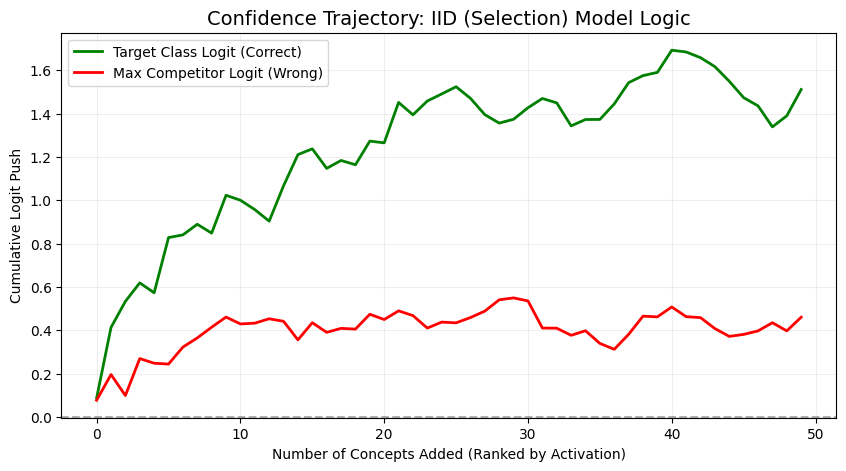

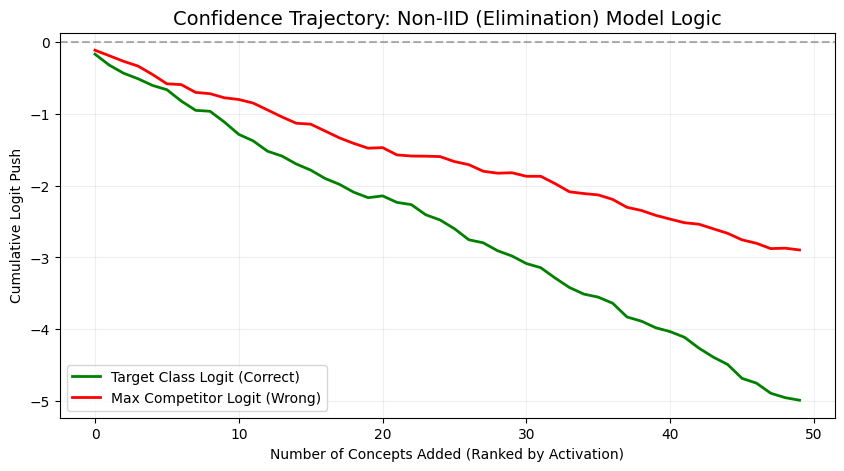

In [44]:
def verify_elimination_mechanics(model, usae, dataloader, model_idx, influence_matrix, label_name):
    model.eval()
    usae.eval()

    # 1. Get a random image
    images, labels = next(iter(dataloader))
    img, label = images[3:4].to(device), labels[3].item()

    with torch.no_grad():
        x = model.pool(torch.relu(model.conv1(img)))
        x = model.pool(torch.relu(model.conv2(x)))
        x = model.pool(torch.relu(model.conv3(x)))

        b, c, h, w = x.shape
        flat_x = rearrange(x, 'b c h w -> (b h w) c')
        Z = usae.encode(flat_x, model_idx)
        z_sums = Z.sum(dim=0).cpu().numpy()

        # 2. Rank concepts by activation strength (the Top-K firing neurons)
        top_indices = np.argsort(z_sums)[::-1][:50] # Top 50 firing concepts

        target_trajectory = []
        competitor_trajectory = []

        current_pushes = np.zeros(n_cls)

        # 3. Add concepts one by one and track the "Logic Trajectory"
        for idx in top_indices:
            concept_push = z_sums[idx] * influence_matrix[idx]
            current_pushes += concept_push

            # Target class score
            target_logit = current_pushes[label]
            # Best wrong class score
            competitor_logit = np.max([current_pushes[c] for c in range(n_cls) if c != label])

            target_trajectory.append(target_logit)
            competitor_trajectory.append(competitor_logit)

    # 4. Plot the results
    plt.figure(figsize=(10, 5))
    plt.plot(target_trajectory, label="Target Class Logit (Correct)", color='green', lw=2)
    plt.plot(competitor_trajectory, label="Max Competitor Logit (Wrong)", color='red', lw=2)
    plt.axhline(0, color='black', linestyle='--', alpha=0.3)
    plt.title(f"Confidence Trajectory: {label_name} Model Logic", fontsize=14)
    plt.xlabel("Number of Concepts Added (Ranked by Activation)")
    plt.ylabel("Cumulative Logit Push")
    plt.legend()
    plt.grid(alpha=0.2)
    plt.show()

# Run the comparison
verify_elimination_mechanics(model_iid, usae, test_loader_iid, 0, inf_iid, "IID (Selection)")
verify_elimination_mechanics(model_niid, usae, test_loader_niid, 1, inf_niid, "Non-IID (Elimination)")